In [19]:
import pandas as pd

# ==========================================
# 1. LOAD DATA
# ==========================================
df = pd.read_csv('/content/data.csv')

print("Shape original :", df.shape)

# ==========================================
# 2. SUPPRESSION COLONNES INUTILES
# ==========================================
cols_to_drop = ['id', 'Unnamed: 32']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("Shape après drop :", df.shape)

# ==========================================
# 3. ENCODAGE TARGET
# ==========================================
if df['diagnosis'].dtype == 'object':
    df['diagnosis'] = df['diagnosis'].map({'B':0, 'M':1})

# ==========================================
# 4. VERIFICATION NaN
# ==========================================
print("\nNaN par colonne :")
print(df.isnull().sum())

print("\nTotal NaN :", df.isnull().sum().sum())

# ==========================================
# 5. TRAITEMENT (sécurité)
# ==========================================
df = df.fillna(df.mean(numeric_only=True))

# ==========================================
# 6. VERIFICATION FINALE
# ==========================================
print("\nAprès nettoyage :")
print(df.isnull().sum().sum())

# ==========================================
# 7. TYPES
# ==========================================
print("\nTypes des colonnes :")
print(df.dtypes)

# ==========================================
# 8. SAVE DATA CLEAN
# ==========================================
output_path = "/content/data_clean.csv"
df.to_csv(output_path, index=False)

print("\n✅ Dataset nettoyé sauvegardé :", output_path)

Shape original : (569, 33)
Shape après drop : (569, 31)

NaN par colonne :
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total NaN : 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


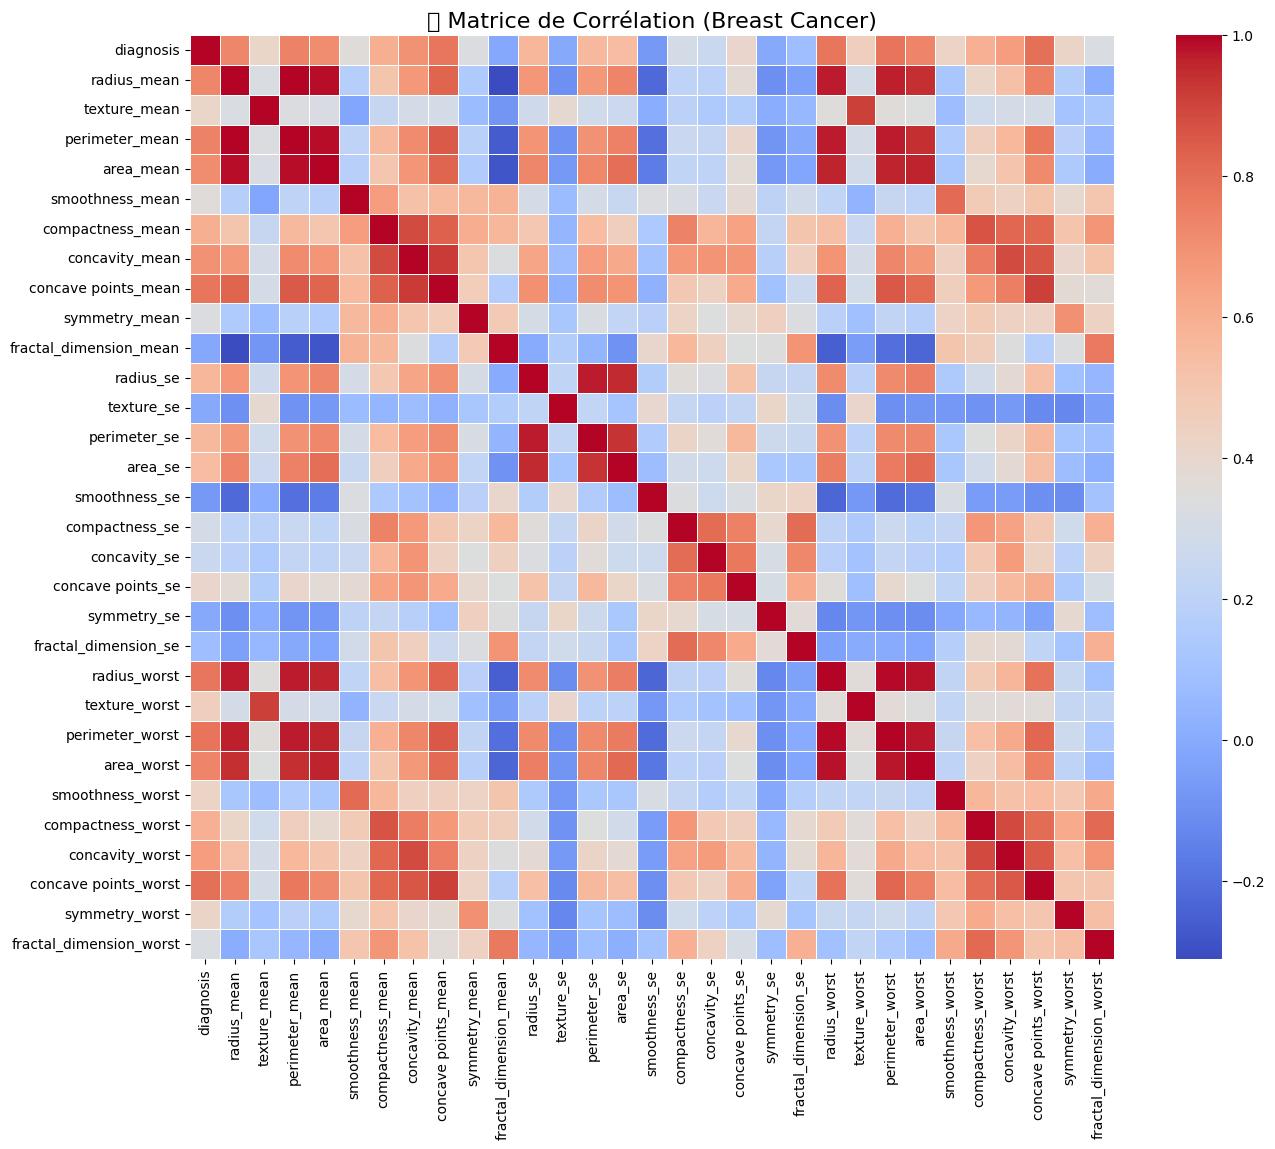

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('/content/data_clean.csv')

plt.figure(figsize=(16,12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    linewidths=0.5,
    annot=False,
    square=True
)

plt.title("🔥 Matrice de Corrélation (Breast Cancer)", fontsize=16)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


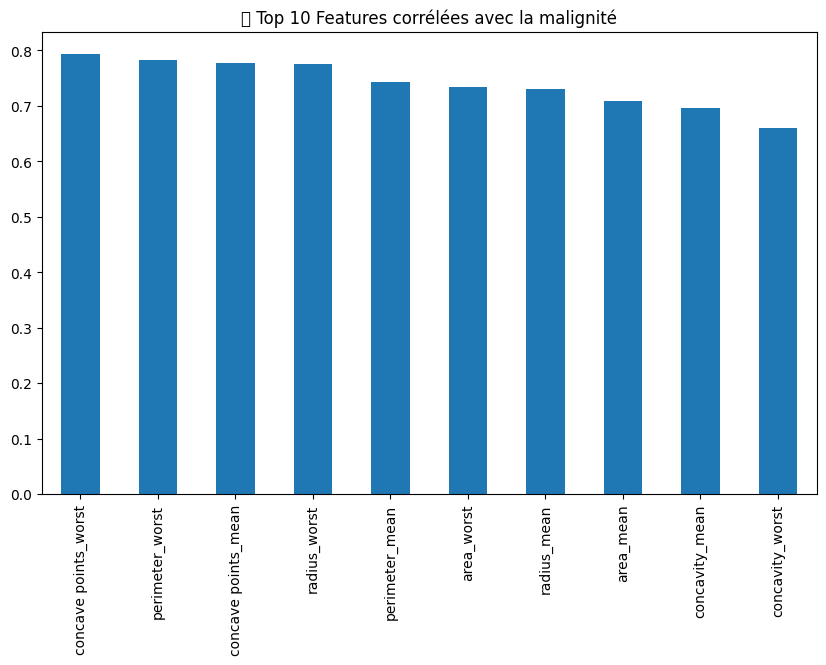

In [21]:
corr_target = corr['diagnosis'].sort_values(ascending=False)

plt.figure(figsize=(10,6))
corr_target[1:].head(10).plot(kind='bar')
plt.title("🚀 Top 10 Features corrélées avec la malignité")
plt.show()

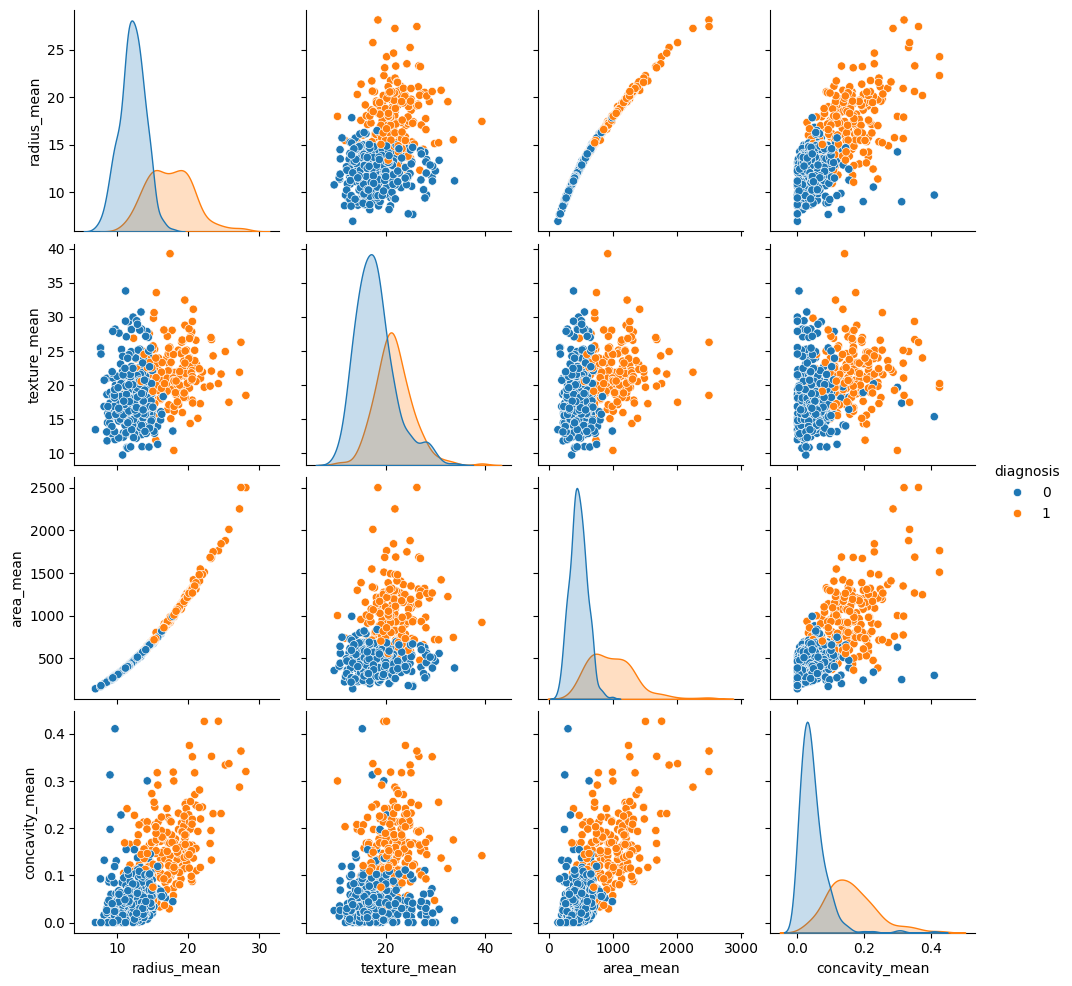

In [22]:
sns.pairplot(
    df[['diagnosis','radius_mean','texture_mean','area_mean','concavity_mean']],
    hue='diagnosis'
)

plt.show()

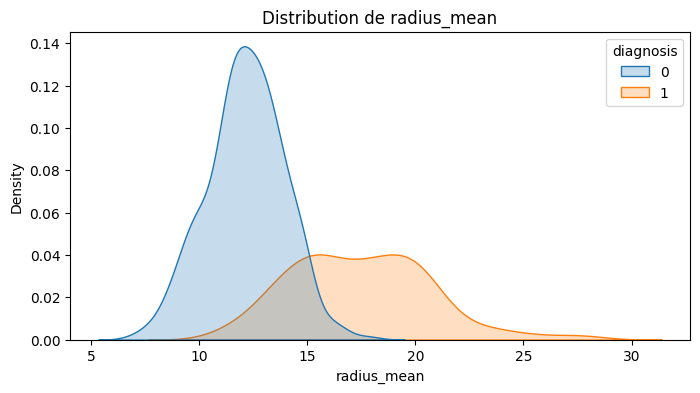

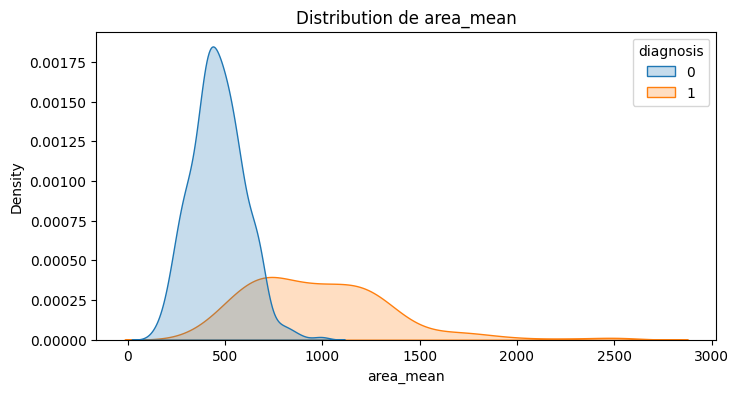

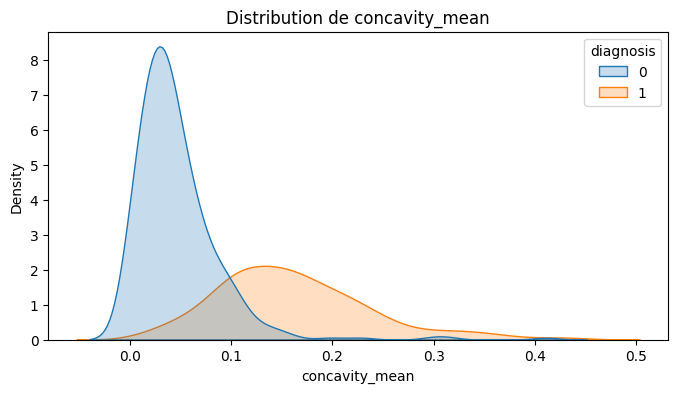

In [23]:
features = ['radius_mean','area_mean','concavity_mean']

for feat in features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=df, x=feat, hue='diagnosis', fill=True)
    plt.title(f"Distribution de {feat}")
    plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


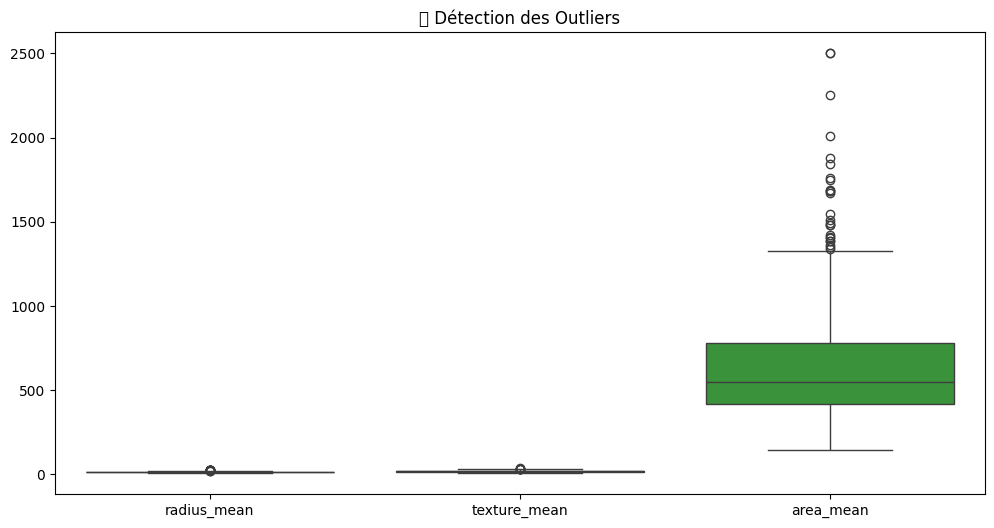

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['radius_mean','texture_mean','area_mean']])

plt.title("📦 Détection des Outliers")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


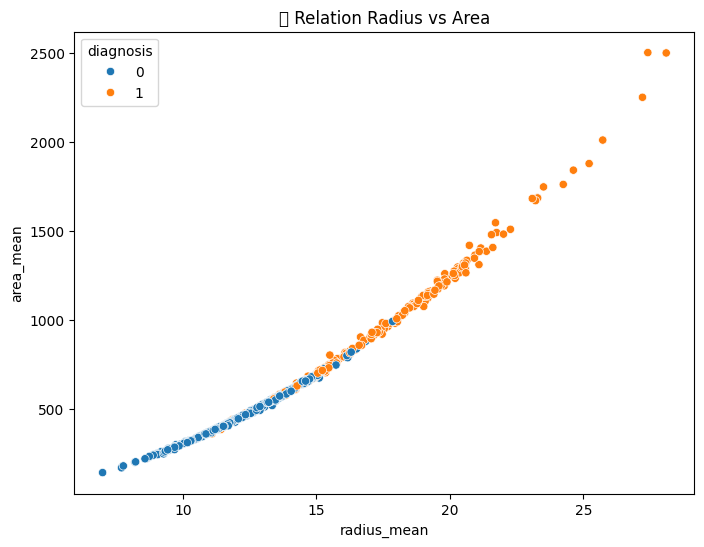

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='radius_mean',
    y='area_mean',
    hue='diagnosis'
)

plt.title("📊 Relation Radius vs Area")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


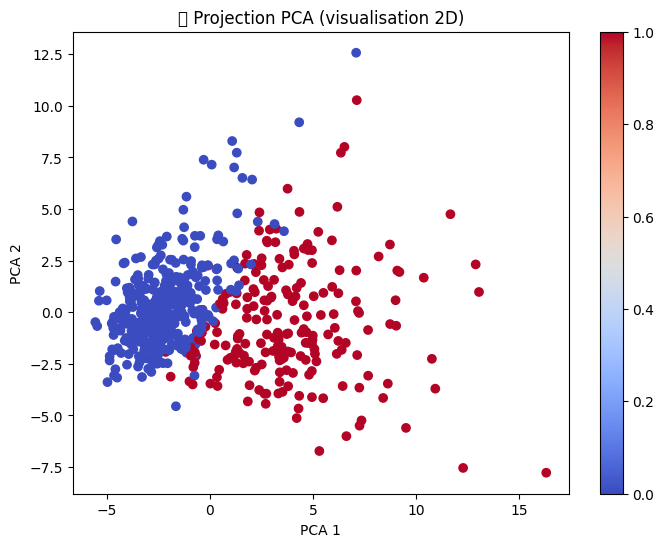

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='coolwarm'
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("🔥 Projection PCA (visualisation 2D)")
plt.colorbar()
plt.show()